1. Loading and Initial Exploration

In [1]:
with interpretation
import pandas as pd

i had a problem in reading the file and i fixed it using double slash \\ in the path 
NOTE FOR DR AHMAD : you might need to change the path 

In [115]:
##Load the dataset into a pandas DataFrame.
df = pd.read_csv('C:\\Users\\chouse\\Downloads\\googleplaystore.csv')

The first 6 rows, the number between () are the number of rows to display from the bigining of the file 

the last 6 rows,the number between () are the number of rows to display from the last row upwards

In [117]:
##Display the first 6 rows and the last 6 rows.
print("First 6 rows:")
display(df.head(6))

print("Last 6 rows:")
display(df.tail(6))

First 6 rows:


,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,7-Jan-18,1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,15-Jan-18,2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,1-Aug-18,1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,8-Jun-18,Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,20-Jun-18,1.1,4.4 and up
5,Paper flowers instructions,ART_AND_DESIGN,4.4,167,5.6M,"50,000+",Free,0,Everyone,Art & Design,26-Mar-17,1,2.3 and up


Last 6 rows:


,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
10835,FR Forms,BUSINESS,NaN,0,9.6M,10+,Free,0,Everyone,Business,29-Sep-16,1.1.5,4.0 and up
10836,Sya9a Maroc - FR,FAMILY,4.5,38,53M,"5,000+",Free,0,Everyone,Education,25-Jul-17,1.48,4.1 and up
10837,Fr. Mike Schmitz Audio Teachings,FAMILY,5.0,4,3.6M,100+,Free,0,Everyone,Education,6-Jul-18,1,4.1 and up
10838,Parkinson Exercices FR,MEDICAL,NaN,3,9.5M,"1,000+",Free,0,Everyone,Medical,20-Jan-17,1,2.2 and up
10839,The SCP Foundation DB fr nn5n,BOOKS_AND_REFERENCE,4.5,114,Varies with device,"1,000+",Free,0,Mature 17+,Books & Reference,19-Jan-15,Varies with device,Varies with device
10840,iHoroscope - 2018 Daily Horoscope & Astrology,LIFESTYLE,4.5,398307,19M,"10,000,000+",Free,0,Everyone,Lifestyle,25-Jul-18,Varies with device,Varies with device


In [119]:
##Show the shape of the dataset (number of rows and columns)
df.shape


(10841, 13)

Shape of the dataset (number of rows and columns).

in the "describe task" i faced many problems because the Insalls collumn was numaric and had the + sign and ",",so i converted the column to string and replaced the + sign to "" using regex ,and at the end of cleaning got the Installs column back to integer value 

In [121]:
##Generate descriptive statistics for numerical columns (e.g., Rating, Reviews, Installs)

df['Installs'] = df['Installs'].astype(str).str.replace('[+,]', '', regex=True).astype(int)
df.describe()

,Rating,Reviews,Installs
count,9367.000000,1.084100e+04,1.084100e+04
mean,4.191513,4.441119e+05,1.546291e+07
std,0.515735,2.927629e+06,8.502557e+07
min,1.000000,0.000000e+00,0.000000e+00
25%,4.000000,3.800000e+01,1.000000e+03
50%,4.300000,2.094000e+03,1.000000e+05
75%,4.500000,5.476800e+04,5.000000e+06
max,5.000000,7.815831e+07,1.000000e+09


-We can see that the average rating is 4.19 for all apps which is considered high.
-The average number of reviews is 444k, but the median is just 2.094k, that means that there are some apps making a huge gap and diffrence and skewing the mean.
-The skewness is also shown in Installs  :mean is 15 million installs, the median is just 100,000.

2. Data Cleaning:

In [127]:
##Print the data types of all columns and check the ability to have null values
pd.DataFrame({'Data type': df.dtypes, 'Ability to have null': df.isnull().any()})

,Data type,Ability to have null
App,object,False
Category,object,True
Rating,float64,True
Reviews,int64,False
Size,object,False
Installs,int32,False
Type,object,True
Price,object,False
Content Rating,object,False
Genres,object,True


That data frame presents the ability to have null values ,if we wanted the number of null values we type "sum()" instead of "any()" to count the null

In [129]:
##Drop rows where Type (Free/Paid) is missing.
df = df.dropna(subset=['Type'])

Looks for the Type column and (dropna) drops any row that has a missing value in column type

In [179]:
##For the Rating column, fill missing values with the median rating of the same app category. Explain why you chose the median.

df['Rating'] = df.groupby('Category')['Rating'].transform( lambda x: x.fillna(x.median()))


------ONLY REPLACING THE EMPTY SLOTS --------
I grouped the apps according to the categery using group by and filled the the missing with the median using transform which makes a transformation to each group, and (lamda) that fills x (the rating)with the median of each group

Why median ??
in our case the mean could be draged very high or very low beacause of outliers on certain app ratings so using the median in a big amount of data would make more sense and make it more reliable and robust 


In [209]:
##Convert the Installs column to a numeric type (remove commas and "+")

df['Installs'] = df['Installs'].astype(str).str.replace('[+,]', '', regex=True).astype(int)
print(df['Installs'].head()) 
##printing to make sure

0       10000
1      500000
2     5000000
3    50000000
4      100000
Name: Installs, dtype: int32


So i converted the column to string and replaced the + sign to "" using regex ,and at the end of cleaning got the Installs column back to integer value

In [237]:
##Convert the Price column to a numeric type ($0.99 → 0.99)

df['Price'] = df['Price'].astype (str).str.replace('$', '', regex=False).astype(float)
print(df['Price'].head())
##printing to make sure

0    0.0
1    0.0
2    0.0
3    0.0
4    0.0
Name: Price, dtype: float64


I converted the column to string and replaced the $ sign to "" using regex ,and at the end of cleaning got the Installs column back to integer value

3. Data Filtering

In [259]:
##Create a new DataFrame containing only free apps (Type = Free)
free_apps = df[df['Type'] == 'Free']
free_apps.head()
##printing to make sure

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,10000,Free,0.0,Everyone,Art & Design,7-Jan-18,1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,500000,Free,0.0,Everyone,Art & Design;Pretend Play,15-Jan-18,2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,5000000,Free,0.0,Everyone,Art & Design,1-Aug-18,1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,50000000,Free,0.0,Teen,Art & Design,8-Jun-18,Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,100000,Free,0.0,Everyone,Art & Design;Creativity,20-Jun-18,1.1,4.4 and up


In [271]:
##Filter apps with a rating greater than 4.5 and more than 1 million installs.

filtered_apps = df[(df['Rating'] > 4.5) & (df['Installs'] > 1000000)]
print(filtered_apps[['App', 'Rating', 'Installs']].head())
##printing to make sure

                                                   App  Rating   Installs
2    U Launcher Lite – FREE Live Cool Themes, Hide ...     4.7    5000000
19                                        ibis Paint X     4.6   10000000
45   Canva: Poster, banner, card maker & graphic de...     4.7   10000000
70   Fines of the State Traffic Safety Inspectorate...     4.8    5000000
139                               Wattpad 📖 Free Books     4.6  100000000


In [291]:
##List the top 3 most installed apps in the "Education" category. Hint (case sensitive)

top_3_apps = df[df['Category'] == 'EDUCATION'].sort_values(by='Installs', ascending=False).head(3)
print(top_3_apps[['App', 'Installs']])

                                App   Installs
699  Duolingo: Learn Languages Free  100000000
826  Duolingo: Learn Languages Free  100000000
799  Duolingo: Learn Languages Free  100000000


searched for only the EDUCATION category and made sure it is higher case (case sensitive)and sorted the data according to Insatalls in the descending order and got the highest 3

4. Grouping and Aggregation

In [301]:
##Group the data by Category and calculate the average rating for each category.

Avg_Rating = df.groupby('Category')['Rating'].mean()
print(Avg_Rating)

Category
ART_AND_DESIGN         4.360000
AUTO_AND_VEHICLES      4.205882
BEAUTY                 4.283019
BOOKS_AND_REFERENCE    4.381385
BUSINESS               4.182391
COMICS                 4.163333
COMMUNICATION          4.182124
DATING                 3.992308
EDUCATION              4.389103
ENTERTAINMENT          4.126174
EVENTS                 4.454688
FAMILY                 4.204515
FINANCE                4.151639
FOOD_AND_DRINK         4.185827
GAME                   4.290997
HEALTH_AND_FITNESS     4.305865
HOUSE_AND_HOME         4.211364
Jazz Wi-Fi             3.400000
LIBRARIES_AND_DEMO     4.183529
LIFESTYLE              4.113613
MAPS_AND_NAVIGATION    4.065693
MEDICAL                4.216199
NEWS_AND_MAGAZINES     4.144170
PARENTING              4.316667
PERSONALIZATION        4.348724
PHOTOGRAPHY            4.197910
PRODUCTIVITY           4.226651
SHOPPING               4.263077
SOCIAL                 4.261017
SPORTS                 4.236458
TOOLS                  4.067141

grouped each Categorty together using (groupby) and I calculated the mean to each one

In [331]:
##Which category has the lowest and highest average rating?

Avg_Rating = df.groupby('Category')['Rating'].mean()
highest_avg = Avg_Rating.idxmax()
highest_value = Avg_Rating.max()

lowest_avg = Avg_Rating.idxmin()
lowest_value = Avg_Rating.min()

print(' Highest Avg Rating:', highest_avg, highest_value)
print(' Lowest Avg Rating:' ,lowest_avg ,lowest_value)

 Highest Avg Rating: EVENTS 4.4546875
 Lowest Avg Rating: Jazz Wi-Fi 3.4


Same as the previous question but i displayed the exact highest and lowest average Rating Category,using idx to get the name of the Categories which is what i (grouped by) with 

In [347]:
##Group the data by Content Rating (e.g., Everyone, Teen) and calculate each group's median and sum number of installs.

CR_info = df.groupby('Content Rating').agg({ 'Installs': ['median', 'sum']})
CR_info

Installs              
                    median           sum
Content Rating                          
Adults only 18+   500000.0       2000000
Everyone          100000.0  114156660621
Everyone 10+     1000000.0   13233881795
Mature 17+        500000.0    5524491178
Teen             1000000.0   34716350393
Unrated            25250.0         50500

I grouped the data by content rating and did aggrigation on the Installs column by calculating both the median and sum for each Content Rating 
We acn tell that(Teen and Everyone 10+) have  the highets  median but it doesnt mean it has the highet installs as we can see (Everyone) has the highest sum of installs by a far number 

5. New Column Creation

In [375]:
##Create a new column, Revenue Estimate for paid apps, by multiplying Price (convert tonumeric) by Installs.


df['Price'] = df['Price'].astype(str).str.replace('$', '').astype(float)

df['Revenue Estimated'] = df[df['Type'] == 'Paid'].apply(lambda x: x['Price'] * x['Installs'], axis=1)

print(df[df['Type'] == 'Paid'][['App', 'Revenue Estimated', 'Installs', 'Price']].head())



                                               App  Revenue Estimated  \
234  TurboScan: scan documents and receipts in PDF           499000.0   
235                 Tiny Scanner Pro: PDF Doc Scan           499000.0   
290  TurboScan: scan documents and receipts in PDF           499000.0   
291                 Tiny Scanner Pro: PDF Doc Scan           499000.0   
427                             Puffin Browser Pro           399000.0   

     Installs  Price  
234    100000   4.99  
235    100000   4.99  
290    100000   4.99  
291    100000   4.99  
427    100000   3.99  


I couldn't display it beside each other (jupyter problem).
I converted  'Price' to a string, remove '$', and then convert to float to make it clean for calculations .
Calculate Revenue Estimated: For only paid apps, by multiplying Price and Installs using lambda(axis =1 means it calculate in row wise(along comums))

6. Visualization

I made sure to drop all missing values before making the histogram

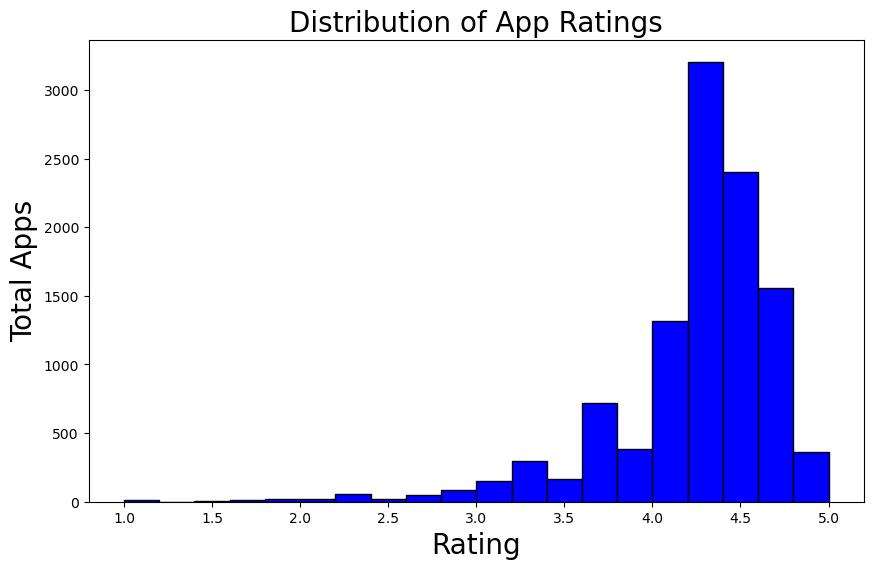

In [423]:
##Use matplotlib to create a histogram of app ratings.
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.hist(df['Rating'].dropna(), bins=20, color='blue', edgecolor='black')

plt.title('Distribution of App Ratings', fontsize=20)
plt.xlabel('Rating', fontsize=20)
plt.ylabel('Total Apps',fontsize=20)

plt.show()


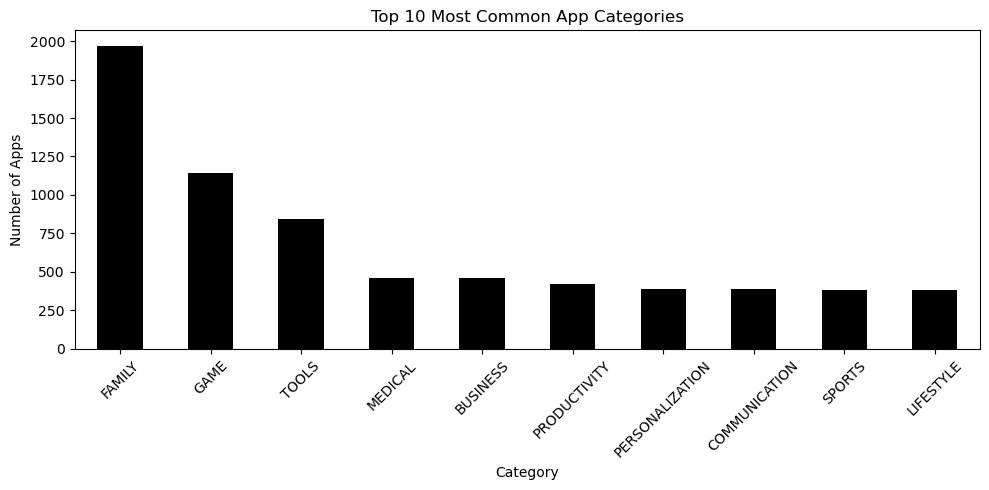

In [431]:
##Create a bar plot showing the top 10 most common app categories.

top_categories = df['Category'].value_counts().head(10)

plt.figure(figsize=(10,5))
top_categories.plot(kind='bar', color='black')

plt.title('Top 10 Most Common App Categories')
plt.xlabel('Category')
plt.ylabel('Number of Apps')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()





I ounted the number of apps in each category using .value_countes() and got the top 10 using .head(10) and chose a vertical bar chart

We can tell that (FAMILY) category is the most common out of all of them with approximately 2000 times in the data out of 10841 